=== CPU Results Data ===
  environment  threads  execution_time  events_per_second
0          VM        1            30.2               7450
1          VM        2            15.1              14920
2   Container        1            29.8               7520
3   Container        2            14.9              15040

=== Statistical Summary ===
                mean   median   min    max          std
environment                                            
Container    11280.0  11280.0  7520  15040  5317.442995
VM           11185.0  11185.0  7450  14920  5282.087655


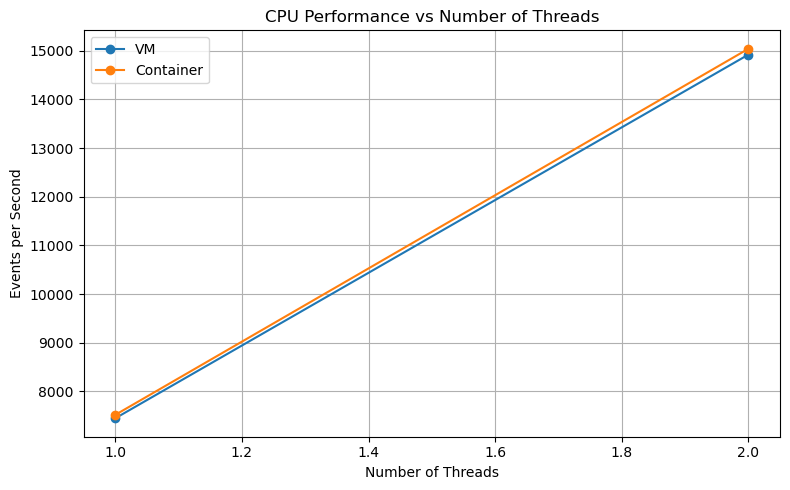

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load the benchmark data
df = pd.read_csv("../results/processed/cpu_results.csv")
print("=== CPU Results Data ===")
print(df)

# 2. Compute statistical summary (Step 22)
stats = df.groupby("environment")["events_per_second"].agg(["mean", "median", "min", "max", "std"])
print("\n=== Statistical Summary ===")
print(stats)

# 3. Plot scalability curves (Step 23)
plt.figure(figsize=(8, 5))
for env in df["environment"].unique():
    subset = df[df["environment"] == env]
    plt.plot(subset["threads"], subset["events_per_second"], marker="o", label=env)

plt.xlabel("Number of Threads")
plt.ylabel("Events per Second")
plt.title("CPU Performance vs Number of Threads")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("../results/figures/cpu_scalability.png", dpi=300)
plt.show()

In [2]:
# 1. Execution Time Difference Formula
vm_time = df[df["environment"] == "VM"]["execution_time"].mean()
container_time = df[df["environment"] == "Container"]["execution_time"].mean()

time_diff = ((vm_time - container_time) / vm_time) * 100
print(f"VM Average Execution Time: {vm_time:.2f}s")
print(f"Container Average Execution Time: {container_time:.2f}s")
print(f"Performance difference (Time): {time_diff:.2f}%")

print("-" * 40)

# 2. Throughput Difference Formula
vm_throughput = df[df["environment"] == "VM"]["events_per_second"].mean()
container_throughput = df[df["environment"] == "Container"]["events_per_second"].mean()

throughput_diff = ((container_throughput - vm_throughput) / vm_throughput) * 100
print(f"VM Average Throughput: {vm_throughput:.2f} events/sec")
print(f"Container Average Throughput: {container_throughput:.2f} events/sec")
print(f"Throughput difference: {throughput_diff:.2f}%")

VM Average Execution Time: 22.65s
Container Average Execution Time: 22.35s
Performance difference (Time): 1.32%
----------------------------------------
VM Average Throughput: 11185.00 events/sec
Container Average Throughput: 11280.00 events/sec
Throughput difference: 0.85%
